In [ ]:
# ============================================================
# CNN → LNN MRI Classification (NINS Dataset, 38 Classes)
# FIXED LOSS FORMULATION – CONVERGING VERSION
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ----------------------------
# Device & Reproducibility
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ----------------------------
# Dataset Path
# ----------------------------
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
NUM_CLASSES = 38
BATCH_SIZE = 16
EPOCHS = 100

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform

        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            cls_path = os.path.join(root_dir, cls)
            if os.path.isdir(cls_path):
                self.classes.append(cls)
                for ext in ("jpg", "jpeg", "png"):
                    self.samples += [
                        (img_path, idx)
                        for img_path in glob.glob(os.path.join(cls_path, f"*.{ext}"))
                    ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")  # 1-channel MRI
        if self.transform:
            img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ============================================================
# LOAD DATASET & SPLIT (70:15:15)
# ============================================================
full_dataset = BrainMRIDataset(ROOT_DIR, transform=None)
N = len(full_dataset)

indices = list(range(N))
random.shuffle(indices)

train_end = int(0.70 * N)
val_end   = int(0.85 * N)

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

train_dataset = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_idx)
val_dataset   = Subset(BrainMRIDataset(ROOT_DIR, val_tfms), val_idx)
test_dataset  = Subset(BrainMRIDataset(ROOT_DIR, val_tfms), test_idx)

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

# ============================================================
# NORMALIZED CLASS WEIGHTS (CORRECT)
# ============================================================
train_labels = [full_dataset.samples[i][1] for i in train_idx]
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)

weights = N / (NUM_CLASSES * class_counts)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

# ============================================================
# LNN
# ============================================================
class LNNLayer(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        return h + torch.tanh(self.fc2(h))

# ============================================================
# CNN → LNN MODEL (1-CHANNEL RESNET50)
# ============================================================
class CNN_LNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)

        cnn_out = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        self.lnn = LNNLayer(cnn_out, 256)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.lnn(x)
        return self.classifier(x)

model = CNN_LNN(NUM_CLASSES).to(device)

# Freeze CNN initially
for p in model.cnn.parameters():
    p.requires_grad = False

# ============================================================
# LOSS, OPTIMIZER, SCHEDULER (FIXED)
# ============================================================
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5, min_lr=1e-6
)

# ============================================================
# TRAIN / VALIDATE
# ============================================================
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    correct, total, loss_sum = 0, 0, 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        if train:
            loss.backward()
            optimizer.step()

        loss_sum += loss.item()
        _, pred = out.max(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), correct / total

# ============================================================
# TRAINING LOOP
# ============================================================
best_val = 0.0

for epoch in range(1, EPOCHS + 1):

    if epoch == 30:
        for p in model.cnn.layer4.parameters():
            p.requires_grad = True
    if epoch == 60:
        for p in model.cnn.layer3.parameters():
            p.requires_grad = True

    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc     = run_epoch(val_loader, False)

    scheduler.step(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "best_cnn_lnn_fixed.pth")

    print(
        f"Epoch [{epoch:03d}/100] | "
        f"TrainAcc: {train_acc:.4f} | ValAcc: {val_acc:.4f} | "
        f"TrainLoss: {train_loss:.4f} | ValLoss: {val_loss:.4f}"
    )

# ============================================================
# TEST EVALUATION
# ============================================================
model.load_state_dict(torch.load("best_cnn_lnn_fixed.pth"))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        _, p = out.max(1)
        y_true.extend(y.numpy())
        y_pred.extend(p.cpu().numpy())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=full_dataset.classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix – CNN-LNN (Fixed)")
plt.colorbar()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

labels = list(range(NUM_CLASSES))

print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=full_dataset.classes,
        zero_division=0
    )
)

In [ ]:
# ============================================================
# CNN → LNN MRI Classification (NINS Dataset)
# 38 Classes → 6 Super-Classes (FINAL, CONVERGING VERSION)
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
BATCH_SIZE = 16
EPOCHS = 80   # 50 is enough for 6-class
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform

        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            path = os.path.join(root_dir, cls)
            if os.path.isdir(path):
                self.classes.append(cls)
                for ext in ("jpg", "jpeg", "png"):
                    self.samples += [(p, idx) for p in glob.glob(os.path.join(path, f"*.{ext}"))]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# ============================================================
# LOAD + SPLIT (70:15:15)
# ============================================================
full_ds = BrainMRIDataset(ROOT_DIR)
N = len(full_ds)
idxs = list(range(N))
random.shuffle(idxs)

train_i = idxs[:int(0.70*N)]
val_i   = idxs[int(0.70*N):int(0.85*N)]
test_i  = idxs[int(0.85*N):]

train_ds = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_i)
val_ds   = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), val_i)
test_ds  = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), test_i)

# ============================================================
# 38 → 6 CLASS REMAPPING
# ============================================================
SUPER_CLASS_MAPPING = {
    "Normal":"Normal",

    "Brain Tumor":"Tumor","Glioma":"Tumor","meningioma":"Tumor","small meningioma":"Tumor",
    "pituitary tumor":"Tumor","Brain Tumor (Ependymoma)":"Tumor",
    "Brain tumor (Astrocytoma Ganglioglioma)":"Tumor",
    "Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)":"Tumor",
    "Brain tumor (Dermoid cyst craniopharyngioma)":"Tumor",
    "Brain tumor - Recurrenceremnant of previous lesion":"Tumor",
    "Postoperative encephalomalacia":"Tumor",
    "Post-operative Status with Small Hemorrhage":"Tumor",

    "Stroke(infarct)":"Stroke","Stroke (Haemorrhage)":"Stroke",
    "Stroke (Demyelination)":"Stroke","Cerebral Hemorrhage":"Stroke",
    "Hemorrhagic collection":"Stroke","Microvascular ischemic change":"Stroke",
    "Small Vessel Diease Demyelination":"Stroke",
    "cerebral venous sinus thrombosis":"Stroke",

    "Brain Infection":"Infection","Brain Infection with abscess":"Infection",
    "Cerebral abscess":"Infection","NMOSD  ADEM":"Infection",
    "demyelinating lesions":"Infection","focal pachymeningitis":"Infection",

    "Brain Atrophy":"Degenerative","Leukoencephalopathy with subcortical cysts":"Degenerative",
    "Encephalomalacia with gliotic change":"Degenerative",
    "White Matter Disease":"Degenerative",
    "Ischemic change  demyelinating plaque":"Degenerative",

    "Obstructive Hydrocephalus":"Structural",
    "Mid triventricular hydrocephalus":"Structural",
    "Malformation (Chiari I)":"Structural",
    "Left Retro-orbital Haemangioma":"Structural"
}

SUPER_CLASSES = ["Normal","Tumor","Stroke","Infection","Degenerative","Structural"]
SUPER_IDX = {c:i for i,c in enumerate(SUPER_CLASSES)}

class RemapDataset(Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, y = self.subset[idx]
        name = self.class_names[y]

        # Safe fallback
        if name not in SUPER_CLASS_MAPPING:
            super_class = "Tumor"
        else:
            super_class = SUPER_CLASS_MAPPING[name]

        return img, SUPER_IDX[super_class]


train_ds = RemapDataset(train_ds, full_ds.classes)
val_ds   = RemapDataset(val_ds, full_ds.classes)
test_ds  = RemapDataset(test_ds, full_ds.classes)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE)
test_loader  = DataLoader(test_ds, BATCH_SIZE)

NUM_CLASSES = 6

# ============================================================
# CLASS WEIGHTS (NORMALIZED)
# ============================================================
train_labels = [y for _,y in train_ds]
counts = np.bincount(train_labels)
weights = len(train_labels) / (NUM_CLASSES * counts)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

# ============================================================
# MODEL (1-CHANNEL RESNET + LNN)
# ============================================================
class LNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d,256)
        self.fc2 = nn.Linear(256,256)

    def forward(self,x):
        h = torch.tanh(self.fc1(x))
        return h + torch.tanh(self.fc2(h))

class CNN_LNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)
        dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()
        self.lnn = LNN(dim)
        self.fc = nn.Linear(256, NUM_CLASSES)

    def forward(self,x):
        x = self.cnn(x)
        x = self.lnn(x)
        return self.fc(x)

model = CNN_LNN().to(device)

# ============================================================
# TRAINING SETUP
# ============================================================
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

def run(loader, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0, 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        if train: optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        if train:
            loss.backward()
            optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1)==y).sum().item()
        total += y.size(0)
    return loss_sum/len(loader), correct/total

# ============================================================
# TRAIN LOOP
# ============================================================
for e in range(1, EPOCHS+1):
    tr_l,tr_a = run(train_loader,True)
    va_l,va_a = run(val_loader,False)
    print(f"Epoch {e:02d} | TrainAcc {tr_a:.3f} | ValAcc {va_a:.3f} | Loss {tr_l:.3f}/{va_l:.3f}")

# ============================================================
# TEST EVALUATION
# ============================================================
y_true,y_pred = [],[]
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_true.extend(y.numpy())
        y_pred.extend(p.numpy())

print("\nClassification Report:\n")
print(classification_report(y_true,y_pred,target_names=SUPER_CLASSES))

cm = confusion_matrix(y_true,y_pred)
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix (6 Classes)")
plt.colorbar()
plt.xticks(range(6),SUPER_CLASSES,rotation=45)
plt.yticks(range(6),SUPER_CLASSES)
plt.show()


In [ ]:
# ============================================================
# CNN → LNN MRI Classification (NINS Dataset)
# 38 Classes → 6 Super-Classes (FINAL, CONVERGING VERSION)
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
BATCH_SIZE = 16
EPOCHS = 80   # 50 is enough for 6-class
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform

        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            path = os.path.join(root_dir, cls)
            if os.path.isdir(path):
                self.classes.append(cls)
                for ext in ("jpg", "jpeg", "png"):
                    self.samples += [(p, idx) for p in glob.glob(os.path.join(path, f"*.{ext}"))]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# ============================================================
# LOAD + SPLIT (70:15:15)
# ============================================================
full_ds = BrainMRIDataset(ROOT_DIR)
N = len(full_ds)
idxs = list(range(N))
random.shuffle(idxs)

train_i = idxs[:int(0.70*N)]
val_i   = idxs[int(0.70*N):int(0.85*N)]
test_i  = idxs[int(0.85*N):]

train_ds = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_i)
val_ds   = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), val_i)
test_ds  = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), test_i)

# ============================================================
# 38 → 6 CLASS REMAPPING
# ============================================================
SUPER_CLASS_MAPPING = {
    "Normal":"Normal",

    "Brain Tumor":"Tumor","Glioma":"Tumor","meningioma":"Tumor","small meningioma":"Tumor",
    "pituitary tumor":"Tumor","Brain Tumor (Ependymoma)":"Tumor",
    "Brain tumor (Astrocytoma Ganglioglioma)":"Tumor",
    "Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)":"Tumor",
    "Brain tumor (Dermoid cyst craniopharyngioma)":"Tumor",
    "Brain tumor - Recurrenceremnant of previous lesion":"Tumor",
    "Postoperative encephalomalacia":"Tumor",
    "Post-operative Status with Small Hemorrhage":"Tumor",

    "Stroke(infarct)":"Stroke","Stroke (Haemorrhage)":"Stroke",
    "Stroke (Demyelination)":"Stroke","Cerebral Hemorrhage":"Stroke",
    "Hemorrhagic collection":"Stroke","Microvascular ischemic change":"Stroke",
    "Small Vessel Diease Demyelination":"Stroke",
    "cerebral venous sinus thrombosis":"Stroke",

    "Brain Infection":"Infection","Brain Infection with abscess":"Infection",
    "Cerebral abscess":"Infection","NMOSD  ADEM":"Infection",
    "demyelinating lesions":"Infection","focal pachymeningitis":"Infection",

    "Brain Atrophy":"Degenerative","Leukoencephalopathy with subcortical cysts":"Degenerative",
    "Encephalomalacia with gliotic change":"Degenerative",
    "White Matter Disease":"Degenerative",
    "Ischemic change  demyelinating plaque":"Degenerative",

    "Obstructive Hydrocephalus":"Structural",
    "Mid triventricular hydrocephalus":"Structural",
    "Malformation (Chiari I)":"Structural",
    "Left Retro-orbital Haemangioma":"Structural"
}
SUPER_CLASSES = ["Normal","Tumor","Stroke","Infection","Degenerative","Structural"]
SUPER_IDX = {c:i for i,c in enumerate(SUPER_CLASSES)}

class RemapDataset(Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, y = self.subset[idx]
        name = self.class_names[y]

        # Safe fallback
        if name not in SUPER_CLASS_MAPPING:
            super_class = "Tumor"
        else:
            super_class = SUPER_CLASS_MAPPING[name]

        return img, SUPER_IDX[super_class]


train_ds = RemapDataset(train_ds, full_ds.classes)
val_ds   = RemapDataset(val_ds, full_ds.classes)
test_ds  = RemapDataset(test_ds, full_ds.classes)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE)
test_loader  = DataLoader(test_ds, BATCH_SIZE)

NUM_CLASSES = 6

# ============================================================
# CLASS WEIGHTS (NORMALIZED)
# ============================================================
train_labels = [y for _,y in train_ds]
counts = np.bincount(train_labels)
weights = len(train_labels) / (NUM_CLASSES * counts)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

# ============================================================
# MODEL (1-CHANNEL RESNET + LNN)
# ============================================================
class LNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d,256)
        self.fc2 = nn.Linear(256,256)

    def forward(self,x):
        h = torch.tanh(self.fc1(x))
        return h + torch.tanh(self.fc2(h))

class CNN_LNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)
        dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()
        self.lnn = LNN(dim)
        self.fc = nn.Linear(256, NUM_CLASSES)

    def forward(self,x):
        x = self.cnn(x)
        x = self.lnn(x)
        return self.fc(x)

model = CNN_LNN().to(device)

# ============================================================
# TRAINING SETUP
# ============================================================
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

def run(loader, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0, 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        if train: optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        if train:
            loss.backward()
            optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1)==y).sum().item()
        total += y.size(0)
    return loss_sum/len(loader), correct/total

# ============================================================
# TRAIN LOOP
# ============================================================
for e in range(1, EPOCHS+1):
    tr_l,tr_a = run(train_loader,True)
    va_l,va_a = run(val_loader,False)
    print(f"Epoch {e:02d} | TrainAcc {tr_a:.3f} | ValAcc {va_a:.3f} | Loss {tr_l:.3f}/{va_l:.3f}")

# ============================================================
# TEST EVALUATION
# ============================================================
y_true,y_pred = [],[]
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_true.extend(y.numpy())
        y_pred.extend(p.numpy())

print("\nClassification Report:\n")
print(classification_report(y_true,y_pred,target_names=SUPER_CLASSES))

cm = confusion_matrix(y_true,y_pred)
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix (6 Classes)")
plt.colorbar()
plt.xticks(range(6),SUPER_CLASSES,rotation=45)
plt.yticks(range(6),SUPER_CLASSES)
plt.show()


In [ ]:
# ============================================================
# CNN → LNN MRI Classification (NINS Dataset)
# 38 Classes → 6 Super-Classes
# 100 Epochs | Train + Val + Test Acc & Loss
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
BATCH_SIZE = 16
EPOCHS = 100

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform

        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            cls_path = os.path.join(root_dir, cls)
            if os.path.isdir(cls_path):
                self.classes.append(cls)
                for ext in ("jpg", "jpeg", "png"):
                    self.samples += [(p, idx) for p in glob.glob(os.path.join(cls_path, f"*.{ext}"))]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# ============================================================
# LOAD + SPLIT (70:15:15)
# ============================================================
full_ds = BrainMRIDataset(ROOT_DIR)
N = len(full_ds)
indices = list(range(N))
random.shuffle(indices)

train_idx = indices[:int(0.70*N)]
val_idx   = indices[int(0.70*N):int(0.85*N)]
test_idx  = indices[int(0.85*N):]

train_ds = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_idx)
val_ds   = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), val_idx)
test_ds  = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), test_idx)

# ============================================================
# 38 → 6 CLASS REMAPPING
# ============================================================
SUPER_CLASS_MAPPING = {
    "Normal":"Normal",

    "Brain Tumor":"Tumor","Glioma":"Tumor","meningioma":"Tumor","small meningioma":"Tumor",
    "pituitary tumor":"Tumor","Brain Tumor (Ependymoma)":"Tumor",
    "Brain tumor (Astrocytoma Ganglioglioma)":"Tumor",
    "Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)":"Tumor",
    "Brain tumor (Dermoid cyst craniopharyngioma)":"Tumor",
    "Brain tumor - Recurrenceremnant of previous lesion":"Tumor",
    "Postoperative encephalomalacia":"Tumor",
    "Post-operative Status with Small Hemorrhage":"Tumor",

    "Stroke(infarct)":"Stroke","Stroke (Haemorrhage)":"Stroke",
    "Stroke (Demyelination)":"Stroke","Cerebral Hemorrhage":"Stroke",
    "Hemorrhagic collection":"Stroke","Microvascular ischemic change":"Stroke",
    "Small Vessel Diease Demyelination":"Stroke",
    "cerebral venous sinus thrombosis":"Stroke",

    "Brain Infection":"Infection","Brain Infection with abscess":"Infection",
    "Cerebral abscess":"Infection","NMOSD  ADEM":"Infection",
    "demyelinating lesions":"Infection","focal pachymeningitis":"Infection",

    "Brain Atrophy":"Degenerative","Leukoencephalopathy with subcortical cysts":"Degenerative",
    "Encephalomalacia with gliotic change":"Degenerative",
    "White Matter Disease":"Degenerative",
    "Ischemic change  demyelinating plaque":"Degenerative",

    "Obstructive Hydrocephalus":"Structural",
    "Mid triventricular hydrocephalus":"Structural",
    "Malformation (Chiari I)":"Structural",
    "Left Retro-orbital Haemangioma":"Structural"
}

SUPER_CLASSES = ["Normal","Tumor","Stroke","Infection","Degenerative","Structural"]
SUPER_IDX = {c:i for i,c in enumerate(SUPER_CLASSES)}

class RemapDataset(Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, y = self.subset[idx]
        name = self.class_names[y]
        super_class = SUPER_CLASS_MAPPING.get(name, "Tumor")
        return img, SUPER_IDX[super_class]

train_ds = RemapDataset(train_ds, full_ds.classes)
val_ds   = RemapDataset(val_ds, full_ds.classes)
test_ds  = RemapDataset(test_ds, full_ds.classes)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE)
test_loader  = DataLoader(test_ds, BATCH_SIZE)

NUM_CLASSES = 6

# ============================================================
# CLASS WEIGHTS
# ============================================================
train_labels = [y for _,y in train_ds]
counts = np.bincount(train_labels)
weights = len(train_labels) / (NUM_CLASSES * counts)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

# ============================================================
# MODEL (1-CHANNEL RESNET + LNN)
# ============================================================
class LNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d,256)
        self.fc2 = nn.Linear(256,256)

    def forward(self,x):
        h = torch.tanh(self.fc1(x))
        return h + torch.tanh(self.fc2(h))

class CNN_LNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)
        dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()
        self.lnn = LNN(dim)
        self.fc = nn.Linear(256, NUM_CLASSES)

    def forward(self,x):
        x = self.cnn(x)
        x = self.lnn(x)
        return self.fc(x)

model = CNN_LNN().to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ============================================================
# EPOCH FUNCTION
# ============================================================
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0, 0, 0

    with torch.set_grad_enabled(train):
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            if train:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item()
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)

    return loss_sum/len(loader), correct/total

# ============================================================
# TRAINING LOOP (TRAIN + VAL + TEST EACH EPOCH)
# ============================================================
train_losses, val_losses, test_losses = [], [], []
train_accs,   val_accs,   test_accs   = [], [], []

for e in range(1, EPOCHS+1):
    tr_l,tr_a = run_epoch(train_loader,True)
    va_l,va_a = run_epoch(val_loader,False)
    te_l,te_a = run_epoch(test_loader,False)

    train_losses.append(tr_l)
    val_losses.append(va_l)
    test_losses.append(te_l)

    train_accs.append(tr_a)
    val_accs.append(va_a)
    test_accs.append(te_a)

    print(
        f"Epoch {e:03d} | "
        f"TrainAcc {tr_a:.3f} | ValAcc {va_a:.3f} | TestAcc {te_a:.3f} | "
        f"Loss {tr_l:.3f}/{va_l:.3f}/{te_l:.3f}"
    )

# ============================================================
# PLOTS (3-CURVE)
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(train_accs,label="Train")
plt.plot(val_accs,label="Val")
plt.plot(test_accs,label="Test")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Train / Val / Test Accuracy")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Val")
plt.plot(test_losses,label="Test")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Train / Val / Test Loss")
plt.legend(); plt.grid(True); plt.show()

# ============================================================
# FINAL TEST EVALUATION
# ============================================================
y_true,y_pred = [],[]
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_true.extend(y.numpy())
        y_pred.extend(p.numpy())

print("\nClassification Report:\n")
print(classification_report(y_true,y_pred,target_names=SUPER_CLASSES))

cm = confusion_matrix(y_true,y_pred)
print("\nConfusion Matrix:\n", cm)

# ============================================================
# TP / TN / FP / FN
# ============================================================
print("\nTP / TN / FP / FN per class")
for i,c in enumerate(SUPER_CLASSES):
    TP = cm[i,i]
    FP = cm[:,i].sum() - TP
    FN = cm[i,:].sum() - TP
    TN = cm.sum() - (TP+FP+FN)
    print(f"{c:12s} | TP={TP} FP={FP} FN={FN} TN={TN}")

plt.figure(figsize=(7,6))
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix (6 Classes)")
plt.colorbar()
plt.xticks(range(6),SUPER_CLASSES,rotation=45)
plt.yticks(range(6),SUPER_CLASSES)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# CNN (5 layers) + LNN (3 layers) MRI Classification
# NINS Dataset | 38 → 6 Super-Classes
# 100 Epochs | Train / Val / Test Metrics
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
BATCH_SIZE = 16
EPOCHS = 100

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform

        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            path = os.path.join(root_dir, cls)
            if os.path.isdir(path):
                self.classes.append(cls)
                for ext in ("jpg", "jpeg", "png"):
                    self.samples += [(p, idx) for p in glob.glob(os.path.join(path, f"*.{ext}"))]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# ============================================================
# LOAD + SPLIT (70:15:15)
# ============================================================
full_ds = BrainMRIDataset(ROOT_DIR)
N = len(full_ds)
idxs = list(range(N))
random.shuffle(idxs)

train_i = idxs[:int(0.70*N)]
val_i   = idxs[int(0.70*N):int(0.85*N)]
test_i  = idxs[int(0.85*N):]

train_ds = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_i)
val_ds   = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), val_i)
test_ds  = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), test_i)

# ============================================================
# 38 → 6 CLASS REMAPPING
# ============================================================
SUPER_CLASS_MAPPING = {
    "Normal":"Normal",
    "Brain Tumor":"Tumor","Glioma":"Tumor","meningioma":"Tumor","small meningioma":"Tumor",
    "pituitary tumor":"Tumor","Brain Tumor (Ependymoma)":"Tumor",
    "Brain tumor (Astrocytoma Ganglioglioma)":"Tumor",
    "Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)":"Tumor",
    "Brain tumor (Dermoid cyst craniopharyngioma)":"Tumor",
    "Brain tumor - Recurrenceremnant of previous lesion":"Tumor",
    "Postoperative encephalomalacia":"Tumor",
    "Post-operative Status with Small Hemorrhage":"Tumor",

    "Stroke(infarct)":"Stroke","Stroke (Haemorrhage)":"Stroke",
    "Stroke (Demyelination)":"Stroke","Cerebral Hemorrhage":"Stroke",
    "Hemorrhagic collection":"Stroke","Microvascular ischemic change":"Stroke",
    "Small Vessel Diease Demyelination":"Stroke",
    "cerebral venous sinus thrombosis":"Stroke",

    "Brain Infection":"Infection","Brain Infection with abscess":"Infection",
    "Cerebral abscess":"Infection","NMOSD  ADEM":"Infection",
    "demyelinating lesions":"Infection","focal pachymeningitis":"Infection",

    "Brain Atrophy":"Degenerative","Leukoencephalopathy with subcortical cysts":"Degenerative",
    "Encephalomalacia with gliotic change":"Degenerative",
    "White Matter Disease":"Degenerative",
    "Ischemic change  demyelinating plaque":"Degenerative",

    "Obstructive Hydrocephalus":"Structural",
    "Mid triventricular hydrocephalus":"Structural",
    "Malformation (Chiari I)":"Structural",
    "Left Retro-orbital Haemangioma":"Structural"
}

SUPER_CLASSES = ["Normal","Tumor","Stroke","Infection","Degenerative","Structural"]
SUPER_IDX = {c:i for i,c in enumerate(SUPER_CLASSES)}

class RemapDataset(Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img,y = self.subset[idx]
        name = self.class_names[y]
        return img, SUPER_IDX[SUPER_CLASS_MAPPING.get(name,"Tumor")]

train_ds = RemapDataset(train_ds, full_ds.classes)
val_ds   = RemapDataset(val_ds, full_ds.classes)
test_ds  = RemapDataset(test_ds, full_ds.classes)

train_loader = DataLoader(train_ds,BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(val_ds,BATCH_SIZE)
test_loader  = DataLoader(test_ds,BATCH_SIZE)

NUM_CLASSES = 6

# ============================================================
# CLASS WEIGHTS
# ============================================================
train_labels = [y for _,y in train_ds]
counts = np.bincount(train_labels)
weights = len(train_labels)/(NUM_CLASSES*counts)
weights = torch.tensor(weights,dtype=torch.float32).to(device)

# ============================================================
# MODEL: 5 CNN + 3 LNN
# ============================================================
class LNNLayer(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Linear(d,d)
    def forward(self,x):
        return x + torch.tanh(self.fc(x))

class CNN_LNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(256,256)
        self.lnn1 = LNNLayer(256)
        self.lnn2 = LNNLayer(256)
        self.lnn3 = LNNLayer(256)
        self.out = nn.Linear(256,NUM_CLASSES)

    def forward(self,x):
        x = self.cnn(x).view(x.size(0),-1)
        x = self.fc(x)
        x = self.lnn1(x)
        x = self.lnn2(x)
        x = self.lnn3(x)
        return self.out(x)

model = CNN_LNN().to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(),lr=1e-4,weight_decay=1e-4)

# ============================================================
# EPOCH FUNCTION
# ============================================================
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0,0,0
    with torch.set_grad_enabled(train):
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            if train:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item()
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)
    return loss_sum/len(loader), correct/total

# ============================================================
# TRAINING LOOP (100 EPOCHS)
# ============================================================
train_losses,val_losses,test_losses = [],[],[]
train_accs,val_accs,test_accs = [],[],[]

for e in range(1,EPOCHS+1):
    tr_l,tr_a = run_epoch(train_loader,True)
    va_l,va_a = run_epoch(val_loader,False)
    te_l,te_a = run_epoch(test_loader,False)

    train_losses.append(tr_l); val_losses.append(va_l); test_losses.append(te_l)
    train_accs.append(tr_a); val_accs.append(va_a); test_accs.append(te_a)

    print(f"Epoch {e:03d} | TrainAcc {tr_a:.3f} | ValAcc {va_a:.3f} | TestAcc {te_a:.3f} | Loss {tr_l:.3f}/{va_l:.3f}/{te_l:.3f}")

# ============================================================
# PLOTS
# ============================================================
plt.figure(); plt.plot(train_accs,label="Train"); plt.plot(val_accs,label="Val"); plt.plot(test_accs,label="Test")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend(); plt.grid(); plt.show()

plt.figure(); plt.plot(train_losses,label="Train"); plt.plot(val_losses,label="Val"); plt.plot(test_losses,label="Test")
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(); plt.show()

# ============================================================
# FINAL EVALUATION
# ============================================================
y_true,y_pred=[],[]
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_true.extend(y.numpy()); y_pred.extend(p.numpy())

print("\nClassification Report\n")
print(classification_report(y_true,y_pred,target_names=SUPER_CLASSES))

cm = confusion_matrix(y_true,y_pred)
print("\nConfusion Matrix\n",cm)

print("\nTP TN FP FN")
for i,c in enumerate(SUPER_CLASSES):
    TP=cm[i,i]; FP=cm[:,i].sum()-TP; FN=cm[i,:].sum()-TP; TN=cm.sum()-(TP+FP+FN)
    print(f"{c:12s} | TP={TP} FP={FP} FN={FN} TN={TN}")


In [ ]:
# ============================================================
# STABLE CNN (5) + LNN (3) MRI CLASSIFIER
# NINS Dataset | 38 → 6 Super-Classes
# 100 Epochs | FULL METRICS
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
BATCH_SIZE = 16
EPOCHS = 100
LR = 3e-5   # 🔑 critical fix

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform
        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            path = os.path.join(root_dir, cls)
            if os.path.isdir(path):
                self.classes.append(cls)
                for ext in ("jpg", "jpeg", "png"):
                    self.samples += [(p, idx) for p in glob.glob(os.path.join(path, f"*.{ext}"))]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform: img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS (SAFE MRI AUGMENTATION)
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# ============================================================
# SPLIT 70 / 15 / 15
# ============================================================
full_ds = BrainMRIDataset(ROOT_DIR)
N = len(full_ds)
idxs = list(range(N))
random.shuffle(idxs)

train_i = idxs[:int(0.70*N)]
val_i   = idxs[int(0.70*N):int(0.85*N)]
test_i  = idxs[int(0.85*N):]

train_ds = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_i)
val_ds   = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), val_i)
test_ds  = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), test_i)

# ============================================================
# 38 → 6 CLASS REMAPPING
# ============================================================
SUPER_CLASS_MAPPING = {
    "Normal":"Normal",
    "Brain Tumor":"Tumor","Glioma":"Tumor","meningioma":"Tumor","small meningioma":"Tumor",
    "pituitary tumor":"Tumor","Brain Tumor (Ependymoma)":"Tumor",
    "Brain tumor (Astrocytoma Ganglioglioma)":"Tumor",
    "Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)":"Tumor",
    "Brain tumor (Dermoid cyst craniopharyngioma)":"Tumor",
    "Brain tumor - Recurrenceremnant of previous lesion":"Tumor",
    "Postoperative encephalomalacia":"Tumor",
    "Post-operative Status with Small Hemorrhage":"Tumor",

    "Stroke(infarct)":"Stroke","Stroke (Haemorrhage)":"Stroke",
    "Stroke (Demyelination)":"Stroke","Cerebral Hemorrhage":"Stroke",
    "Hemorrhagic collection":"Stroke","Microvascular ischemic change":"Stroke",
    "Small Vessel Diease Demyelination":"Stroke",
    "cerebral venous sinus thrombosis":"Stroke",

    "Brain Infection":"Infection","Brain Infection with abscess":"Infection",
    "Cerebral abscess":"Infection","NMOSD  ADEM":"Infection",
    "demyelinating lesions":"Infection","focal pachymeningitis":"Infection",

    "Brain Atrophy":"Degenerative","Leukoencephalopathy with subcortical cysts":"Degenerative",
    "Encephalomalacia with gliotic change":"Degenerative",
    "White Matter Disease":"Degenerative",
    "Ischemic change  demyelinating plaque":"Degenerative",

    "Obstructive Hydrocephalus":"Structural",
    "Mid triventricular hydrocephalus":"Structural",
    "Malformation (Chiari I)":"Structural",
    "Left Retro-orbital Haemangioma":"Structural"
}

SUPER_CLASSES = ["Normal","Tumor","Stroke","Infection","Degenerative","Structural"]
SUPER_IDX = {c:i for i,c in enumerate(SUPER_CLASSES)}

class RemapDataset(Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img,y = self.subset[idx]
        name = self.class_names[y]
        return img, SUPER_IDX[SUPER_CLASS_MAPPING.get(name,"Tumor")]

train_ds = RemapDataset(train_ds, full_ds.classes)
val_ds   = RemapDataset(val_ds, full_ds.classes)
test_ds  = RemapDataset(test_ds, full_ds.classes)

train_loader = DataLoader(train_ds,BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(val_ds,BATCH_SIZE)
test_loader  = DataLoader(test_ds,BATCH_SIZE)

# ============================================================
# CLASS WEIGHTS (NORMALIZED)
# ============================================================
labels = [y for _,y in train_ds]
counts = np.bincount(labels)
weights = len(labels)/(len(counts)*counts)
weights = torch.tensor(weights,dtype=torch.float32).to(device)

# ============================================================
# MODEL: BALANCED CNN + LNN
# ============================================================
class LNNLayer(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Linear(d,d)
    def forward(self,x):
        return x + torch.tanh(self.fc(x))

class CNN_LNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256,512,3,padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(512,256),
            nn.Dropout(0.3)
        )
        self.lnn1 = LNNLayer(256)
        self.lnn2 = LNNLayer(256)
        self.lnn3 = LNNLayer(256)
        self.out = nn.Linear(256,6)

    def forward(self,x):
        x = self.cnn(x).view(x.size(0),-1)
        x = self.fc(x)
        x = self.lnn1(x)
        x = self.lnn2(x)
        x = self.lnn3(x)
        return self.out(x)

model = CNN_LNN().to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(),lr=LR,weight_decay=1e-4)

# ============================================================
# EPOCH FUNCTION
# ============================================================
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0,0,0
    with torch.set_grad_enabled(train):
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            if train:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item()
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)
    return loss_sum/len(loader), correct/total

# ============================================================
# TRAINING LOOP
# ============================================================
train_accs,val_accs,test_accs = [],[],[]
train_losses,val_losses,test_losses = [],[],[]

for e in range(1,EPOCHS+1):
    tr_l,tr_a = run_epoch(train_loader,True)
    va_l,va_a = run_epoch(val_loader,False)
    te_l,te_a = run_epoch(test_loader,False)

    train_losses.append(tr_l); val_losses.append(va_l); test_losses.append(te_l)
    train_accs.append(tr_a); val_accs.append(va_a); test_accs.append(te_a)

    print(f"Epoch {e:03d} | TrainAcc {tr_a:.3f} | ValAcc {va_a:.3f} | TestAcc {te_a:.3f} | Loss {tr_l:.3f}/{va_l:.3f}/{te_l:.3f}")

# ============================================================
# PLOTS
# ============================================================
plt.figure(); plt.plot(train_accs,label="Train"); plt.plot(val_accs,label="Val"); plt.plot(test_accs,label="Test")
plt.title("Accuracy"); plt.legend(); plt.grid(); plt.show()

plt.figure(); plt.plot(train_losses,label="Train"); plt.plot(val_losses,label="Val"); plt.plot(test_losses,label="Test")
plt.title("Loss"); plt.legend(); plt.grid(); plt.show()

# ============================================================
# FINAL TEST EVALUATION
# ============================================================
y_true,y_pred=[],[]
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_true.extend(y.numpy()); y_pred.extend(p.numpy())

print("\nClassification Report\n")
print(classification_report(y_true,y_pred,target_names=SUPER_CLASSES))

cm = confusion_matrix(y_true,y_pred)
print("\nConfusion Matrix\n",cm)

print("\nTP TN FP FN")
for i,c in enumerate(SUPER_CLASSES):
    TP=cm[i,i]; FP=cm[:,i].sum()-TP; FN=cm[i,:].sum()-TP; TN=cm.sum()-(TP+FP+FN)
    print(f"{c:12s} | TP={TP} FP={FP} FN={FN} TN={TN}")


In [ ]:
# ============================================================
# ResNet-18 + LNN MRI Classification (BALANCED VERSION)
# NINS Dataset | 38 → 6 Super-Classes
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
BATCH_SIZE = 16
EPOCHS = 100
LR = 3e-5

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform
        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            path = os.path.join(root_dir, cls)
            if os.path.isdir(path):
                self.classes.append(cls)
                for ext in ("jpg","jpeg","png"):
                    self.samples += [(p, idx) for p in glob.glob(os.path.join(path,f"*.{ext}"))]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform: img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# ============================================================
# SPLIT 70 / 15 / 15
# ============================================================
full_ds = BrainMRIDataset(ROOT_DIR)
N = len(full_ds)
idxs = list(range(N))
random.shuffle(idxs)

train_i = idxs[:int(0.70*N)]
val_i   = idxs[int(0.70*N):int(0.85*N)]
test_i  = idxs[int(0.85*N):]

train_ds = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_i)
val_ds   = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), val_i)
test_ds  = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), test_i)

# ============================================================
# 38 → 6 CLASS REMAPPING
# ============================================================
SUPER_CLASS_MAPPING = {
    "Normal":"Normal",

    "Brain Tumor":"Tumor","Glioma":"Tumor","meningioma":"Tumor","small meningioma":"Tumor",
    "pituitary tumor":"Tumor","Brain Tumor (Ependymoma)":"Tumor",
    "Brain tumor (Astrocytoma Ganglioglioma)":"Tumor",
    "Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)":"Tumor",
    "Brain tumor (Dermoid cyst craniopharyngioma)":"Tumor",
    "Brain tumor - Recurrenceremnant of previous lesion":"Tumor",
    "Postoperative encephalomalacia":"Tumor",
    "Post-operative Status with Small Hemorrhage":"Tumor",

    "Stroke(infarct)":"Stroke","Stroke (Haemorrhage)":"Stroke",
    "Stroke (Demyelination)":"Stroke","Cerebral Hemorrhage":"Stroke",
    "Hemorrhagic collection":"Stroke","Microvascular ischemic change":"Stroke",
    "Small Vessel Diease Demyelination":"Stroke",
    "cerebral venous sinus thrombosis":"Stroke",

    "Brain Infection":"Infection","Brain Infection with abscess":"Infection",
    "Cerebral abscess":"Infection","NMOSD  ADEM":"Infection",
    "demyelinating lesions":"Infection","focal pachymeningitis":"Infection",

    "Brain Atrophy":"Degenerative","Leukoencephalopathy with subcortical cysts":"Degenerative",
    "Encephalomalacia with gliotic change":"Degenerative",
    "White Matter Disease":"Degenerative",
    "Ischemic change  demyelinating plaque":"Degenerative",

    "Obstructive Hydrocephalus":"Structural",
    "Mid triventricular hydrocephalus":"Structural",
    "Malformation (Chiari I)":"Structural",
    "Left Retro-orbital Haemangioma":"Structural"
}

SUPER_CLASSES = ["Normal","Tumor","Stroke","Infection","Degenerative","Structural"]
SUPER_IDX = {c:i for i,c in enumerate(SUPER_CLASSES)}

class RemapDataset(Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img,y = self.subset[idx]
        name = self.class_names[y]
        return img, SUPER_IDX[SUPER_CLASS_MAPPING.get(name,"Tumor")]

train_ds = RemapDataset(train_ds, full_ds.classes)
val_ds   = RemapDataset(val_ds, full_ds.classes)
test_ds  = RemapDataset(test_ds, full_ds.classes)

train_loader = DataLoader(train_ds,BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(val_ds,BATCH_SIZE)
test_loader  = DataLoader(test_ds,BATCH_SIZE)

# ============================================================
# CLASS WEIGHTS
# ============================================================
labels = [y for _,y in train_ds]
counts = np.bincount(labels)
weights = len(labels)/(len(counts)*counts)
weights = torch.tensor(weights,dtype=torch.float32).to(device)

# ============================================================
# MODEL: ResNet-18 + 3-Layer LNN
# ============================================================
class LNNLayer(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Linear(d,d)
    def forward(self,x):
        return x + torch.tanh(self.fc(x))

class ResNet18_LNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.cnn.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)
        dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        self.fc = nn.Sequential(
            nn.Linear(dim,256),
            nn.Dropout(0.3)
        )
        self.lnn1 = LNNLayer(256)
        self.lnn2 = LNNLayer(256)
        self.lnn3 = LNNLayer(256)
        self.out = nn.Linear(256,6)

    def forward(self,x):
        x = self.cnn(x)
        x = self.fc(x)
        x = self.lnn1(x)
        x = self.lnn2(x)
        x = self.lnn3(x)
        return self.out(x)

model = ResNet18_LNN().to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(),lr=LR,weight_decay=1e-4)

# ============================================================
# TRAIN / EVAL FUNCTION
# ============================================================
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0,0,0
    with torch.set_grad_enabled(train):
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            if train:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item()
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)
    return loss_sum/len(loader), correct/total

# ============================================================
# TRAINING LOOP
# ============================================================
for e in range(1,EPOCHS+1):
    tr_l,tr_a = run_epoch(train_loader,True)
    va_l,va_a = run_epoch(val_loader,False)
    te_l,te_a = run_epoch(test_loader,False)
    print(f"Epoch {e:03d} | TrainAcc {tr_a:.3f} | ValAcc {va_a:.3f} | TestAcc {te_a:.3f} | Loss {tr_l:.3f}/{va_l:.3f}/{te_l:.3f}")

# ============================================================
# FINAL TEST EVALUATION
# ============================================================
y_true,y_pred=[],[]
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_true.extend(y.numpy()); y_pred.extend(p.numpy())

print("\nClassification Report\n")
print(classification_report(y_true,y_pred,target_names=SUPER_CLASSES))

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(7,6))
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix (ResNet-18 + LNN)")
plt.colorbar()
plt.xticks(range(6),SUPER_CLASSES,rotation=45)
plt.yticks(range(6),SUPER_CLASSES)
plt.tight_layout()
plt.show()
print("\nTP / TN / FP / FN per class\n")

for i, cls in enumerate(SUPER_CLASSES):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    print(
        f"{cls:12s} | "
        f"TP={TP:4d}  FP={FP:4d}  FN={FN:4d}  TN={TN:4d}"
    )


In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 101))

train_acc = [
0.280,0.390,0.456,0.551,0.620,0.658,0.699,0.744,0.785,0.810,
0.828,0.844,0.867,0.885,0.894,0.888,0.909,0.935,0.917,0.922,
0.926,0.941,0.936,0.934,0.942,0.939,0.936,0.959,0.956,0.962,
0.949,0.932,0.948,0.962,0.970,0.968,0.955,0.962,0.959,0.964,
0.957,0.961,0.967,0.964,0.968,0.968,0.962,0.969,0.982,0.968,
0.974,0.965,0.977,0.962,0.973,0.981,0.974,0.970,0.977,0.980,
0.981,0.967,0.971,0.975,0.963,0.981,0.983,0.980,0.983,0.977,
0.989,0.980,0.972,0.977,0.984,0.977,0.987,0.983,0.969,0.978,
0.982,0.992,0.984,0.960,0.965,0.983,0.990,0.985,0.980,0.989,
0.986,0.978,0.983,0.990,0.984,0.980,0.983,0.979,0.974,0.984
]

val_acc = [
0.356,0.464,0.484,0.513,0.576,0.614,0.630,0.682,0.663,0.695,
0.715,0.720,0.748,0.738,0.753,0.747,0.781,0.781,0.727,0.762,
0.802,0.789,0.816,0.804,0.821,0.790,0.807,0.825,0.812,0.792,
0.808,0.802,0.827,0.823,0.830,0.816,0.762,0.807,0.775,0.822,
0.798,0.808,0.821,0.828,0.832,0.840,0.808,0.820,0.832,0.811,
0.844,0.822,0.832,0.831,0.821,0.841,0.835,0.818,0.822,0.831,
0.823,0.779,0.818,0.835,0.837,0.820,0.832,0.806,0.840,0.821,
0.858,0.830,0.830,0.816,0.846,0.842,0.846,0.837,0.799,0.836,
0.832,0.839,0.844,0.811,0.822,0.846,0.849,0.845,0.855,0.855,
0.846,0.849,0.856,0.851,0.840,0.837,0.853,0.848,0.851,0.844
]

test_acc = [
0.334,0.445,0.492,0.504,0.553,0.584,0.607,0.661,0.674,0.701,
0.711,0.716,0.740,0.739,0.742,0.741,0.756,0.760,0.736,0.750,
0.793,0.784,0.798,0.789,0.820,0.782,0.816,0.816,0.839,0.797,
0.794,0.796,0.825,0.816,0.819,0.827,0.779,0.810,0.789,0.830,
0.798,0.835,0.830,0.830,0.824,0.820,0.794,0.812,0.830,0.806,
0.832,0.810,0.813,0.822,0.813,0.822,0.821,0.815,0.813,0.827,
0.830,0.783,0.855,0.834,0.841,0.835,0.841,0.815,0.846,0.829,
0.864,0.825,0.827,0.832,0.858,0.839,0.848,0.838,0.813,0.862,
0.869,0.862,0.849,0.821,0.840,0.850,0.849,0.829,0.852,0.838,
0.844,0.845,0.850,0.846,0.840,0.819,0.855,0.830,0.845,0.841
]

plt.figure()
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.plot(epochs, test_acc, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ============================================================
# CNN (ResNet-18 equivalent) + LNN MRI Classification
# NINS Dataset | 38 → 6 Super-Classes
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
BATCH_SIZE = 16
EPOCHS = 100
LR = 3e-5

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform
        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            path = os.path.join(root_dir, cls)
            if os.path.isdir(path):
                self.classes.append(cls)
                for ext in ("jpg", "jpeg", "png"):
                    self.samples += [(p, idx) for p in glob.glob(os.path.join(path, f"*.{ext}"))]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# ============================================================
# SPLIT 70 / 15 / 15
# ============================================================
full_ds = BrainMRIDataset(ROOT_DIR)
N = len(full_ds)
idxs = list(range(N))
random.shuffle(idxs)

train_i = idxs[:int(0.70 * N)]
val_i   = idxs[int(0.70 * N):int(0.85 * N)]
test_i  = idxs[int(0.85 * N):]

train_ds = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_i)
val_ds   = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), val_i)
test_ds  = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), test_i)

# ============================================================
# 38 → 6 CLASS REMAPPING
# ============================================================
SUPER_CLASS_MAPPING = {
    "Normal": "Normal",

    "Brain Tumor": "Tumor", "Glioma": "Tumor", "meningioma": "Tumor",
    "small meningioma": "Tumor", "pituitary tumor": "Tumor",
    "Brain Tumor (Ependymoma)": "Tumor",
    "Brain tumor (Astrocytoma Ganglioglioma)": "Tumor",
    "Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)": "Tumor",
    "Brain tumor (Dermoid cyst craniopharyngioma)": "Tumor",
    "Brain tumor - Recurrenceremnant of previous lesion": "Tumor",
    "Postoperative encephalomalacia": "Tumor",
    "Post-operative Status with Small Hemorrhage": "Tumor",

    "Stroke(infarct)": "Stroke", "Stroke (Haemorrhage)": "Stroke",
    "Stroke (Demyelination)": "Stroke", "Cerebral Hemorrhage": "Stroke",
    "Hemorrhagic collection": "Stroke",
    "Microvascular ischemic change": "Stroke",
    "Small Vessel Diease Demyelination": "Stroke",
    "cerebral venous sinus thrombosis": "Stroke",

    "Brain Infection": "Infection", "Brain Infection with abscess": "Infection",
    "Cerebral abscess": "Infection", "NMOSD  ADEM": "Infection",
    "demyelinating lesions": "Infection", "focal pachymeningitis": "Infection",

    "Brain Atrophy": "Degenerative",
    "Leukoencephalopathy with subcortical cysts": "Degenerative",
    "Encephalomalacia with gliotic change": "Degenerative",
    "White Matter Disease": "Degenerative",
    "Ischemic change  demyelinating plaque": "Degenerative",

    "Obstructive Hydrocephalus": "Structural",
    "Mid triventricular hydrocephalus": "Structural",
    "Malformation (Chiari I)": "Structural",
    "Left Retro-orbital Haemangioma": "Structural"
}

SUPER_CLASSES = ["Normal", "Tumor", "Stroke", "Infection", "Degenerative", "Structural"]
SUPER_IDX = {c: i for i, c in enumerate(SUPER_CLASSES)}

class RemapDataset(Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, y = self.subset[idx]
        name = self.class_names[y]
        return img, SUPER_IDX[SUPER_CLASS_MAPPING.get(name, "Tumor")]

train_ds = RemapDataset(train_ds, full_ds.classes)
val_ds   = RemapDataset(val_ds, full_ds.classes)
test_ds  = RemapDataset(test_ds, full_ds.classes)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE)
test_loader  = DataLoader(test_ds, BATCH_SIZE)

# ============================================================
# CLASS WEIGHTS
# ============================================================
labels = [y for _, y in train_ds]
counts = np.bincount(labels)
weights = len(labels) / (len(counts) * counts)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

# ============================================================
# CNN (ResNet-18 equivalent, NO skip connections)
# ============================================================
class CNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class CNN_ResNet18_Backbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, 7, 2, 3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2, 1)
        )

        self.layer1 = nn.Sequential(
            CNNBlock(64, 64, 1),
            CNNBlock(64, 64, 1)
        )
        self.layer2 = nn.Sequential(
            CNNBlock(64, 128, 2),
            CNNBlock(128, 128, 1)
        )
        self.layer3 = nn.Sequential(
            CNNBlock(128, 256, 2),
            CNNBlock(256, 256, 1)
        )
        self.layer4 = nn.Sequential(
            CNNBlock(256, 512, 2),
            CNNBlock(512, 512, 1)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        return torch.flatten(x, 1)

# ============================================================
# LNN + CLASSIFIER
# ============================================================
class LNNLayer(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Linear(d, d)

    def forward(self, x):
        return x + torch.tanh(self.fc(x))

class CNN18_LNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNN_ResNet18_Backbone()

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.Dropout(0.3)
        )

        self.lnn1 = LNNLayer(256)
        self.lnn2 = LNNLayer(256)
        self.lnn3 = LNNLayer(256)

        self.out = nn.Linear(256, 6)

    def forward(self, x):
        x = self.cnn(x)
        x = self.fc(x)
        x = self.lnn1(x)
        x = self.lnn2(x)
        x = self.lnn3(x)
        return self.out(x)

model = CNN18_LNN().to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# ============================================================
# TRAIN / EVAL
# ============================================================
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0, 0, 0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()

            out = model(x)
            loss = criterion(out, y)

            if train:
                loss.backward()
                optimizer.step()

            loss_sum += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), correct / total

# ============================================================
# TRAINING LOOP
# ============================================================
for e in range(1, EPOCHS + 1):
    tr_l, tr_a = run_epoch(train_loader, True)
    va_l, va_a = run_epoch(val_loader, False)
    te_l, te_a = run_epoch(test_loader, False)
    print(f"Epoch {e:03d} | TrainAcc {tr_a:.3f} | ValAcc {va_a:.3f} | TestAcc {te_a:.3f} | "
          f"Loss {tr_l:.3f}/{va_l:.3f}/{te_l:.3f}")

# ============================================================
# FINAL EVALUATION
# ============================================================
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_true.extend(y.numpy())
        y_pred.extend(p.numpy())

print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=SUPER_CLASSES))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (CNN-18 + LNN)")
plt.colorbar()
plt.xticks(range(6), SUPER_CLASSES, rotation=45)
plt.yticks(range(6), SUPER_CLASSES)
plt.tight_layout()
plt.show()

print("\nTP / TN / FP / FN per class\n")
for i, cls in enumerate(SUPER_CLASSES):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    print(f"{cls:12s} | TP={TP:4d}  FP={FP:4d}  FN={FN:4d}  TN={TN:4d}")


Class weights:
Normal      : 0.565
Tumor       : 0.830
Stroke      : 0.551
Infection   : 1.463
Degenerative: 1.086
Structural  : 1.506
Epoch 001 | TrainAcc 0.277 | ValAcc 0.224 | TestAcc 0.204 | Loss 0.691/0.676/0.631
Epoch 002 | TrainAcc 0.319 | ValAcc 0.296 | TestAcc 0.272 | Loss 0.623/0.622/0.624
Epoch 003 | TrainAcc 0.322 | ValAcc 0.302 | TestAcc 0.272 | Loss 0.580/0.591/0.572
Epoch 004 | TrainAcc 0.336 | ValAcc 0.247 | TestAcc 0.225 | Loss 0.545/0.663/0.688
Epoch 005 | TrainAcc 0.359 | ValAcc 0.436 | TestAcc 0.430 | Loss 0.509/0.480/0.462
Epoch 006 | TrainAcc 0.399 | ValAcc 0.421 | TestAcc 0.431 | Loss 0.460/0.469/0.437
Epoch 007 | TrainAcc 0.426 | ValAcc 0.419 | TestAcc 0.378 | Loss 0.428/0.430/0.456
Epoch 008 | TrainAcc 0.449 | ValAcc 0.445 | TestAcc 0.447 | Loss 0.375/0.409/0.407
Epoch 009 | TrainAcc 0.481 | ValAcc 0.502 | TestAcc 0.471 | Loss 0.330/0.390/0.363
Epoch 010 | TrainAcc 0.516 | ValAcc 0.537 | TestAcc 0.505 | Loss 0.308/0.413/0.369
Epoch 011 | TrainAcc 0.548 | ValAcc

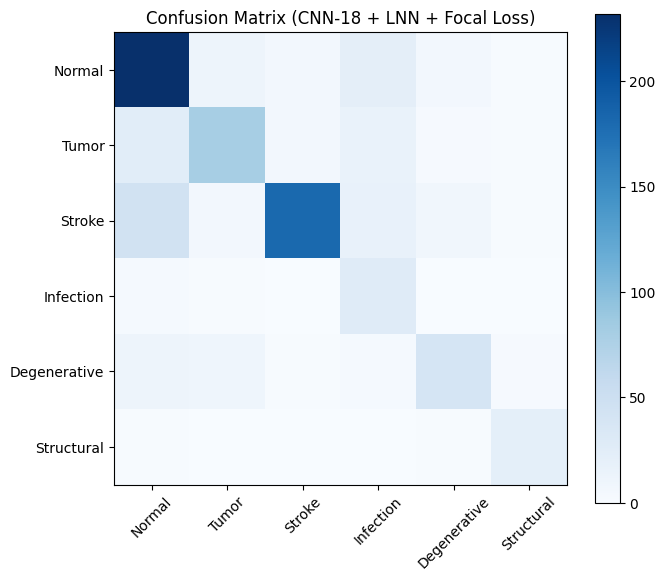


TP / TN / FP / FN per class

Normal       | TP= 232 FP=  85 FN=  46 TN= 425
Tumor        | TP=  80 FP=  28 FN=  50 TN= 630
Stroke       | TP= 181 FP=  13 FN=  78 TN= 516
Infection    | TP=  28 FP=  59 FN=   4 TN= 697
Degenerative | TP=  39 FP=  17 FN=  27 TN= 705
Structural   | TP=  21 FP=   5 FN=   2 TN= 760


In [1]:
# ============================================================
# CNN-18 (ResNet-18 equivalent) + LNN
# HIGH PENALTY FOR RARE CLASSES (FOCAL LOSS)
# NINS Dataset | 38 → 6 Super-Classes
# ============================================================

import os, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT_DIR = "/kaggle/input/mri-dataset-for-detection-and-analysis/NINS_Dataset/NINS_Dataset"
BATCH_SIZE = 16
EPOCHS = 100
LR = 3e-5

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# DATASET
# ============================================================
class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.classes = []
        self.transform = transform
        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            path = os.path.join(root_dir, cls)
            if os.path.isdir(path):
                self.classes.append(cls)
                for ext in ("jpg","jpeg","png"):
                    self.samples += [(p, idx) for p in glob.glob(os.path.join(path,f"*.{ext}"))]

    def __len__(self): 
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# ============================================================
# SPLIT 70 / 15 / 15
# ============================================================
full_ds = BrainMRIDataset(ROOT_DIR)
N = len(full_ds)
idxs = list(range(N))
random.shuffle(idxs)

train_i = idxs[:int(0.70*N)]
val_i   = idxs[int(0.70*N):int(0.85*N)]
test_i  = idxs[int(0.85*N):]

train_ds = Subset(BrainMRIDataset(ROOT_DIR, train_tfms), train_i)
val_ds   = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), val_i)
test_ds  = Subset(BrainMRIDataset(ROOT_DIR, test_tfms), test_i)

# ============================================================
# 38 → 6 CLASS REMAPPING
# ============================================================
SUPER_CLASS_MAPPING = {
    "Normal":"Normal",

    "Brain Tumor":"Tumor","Glioma":"Tumor","meningioma":"Tumor","small meningioma":"Tumor",
    "pituitary tumor":"Tumor","Brain Tumor (Ependymoma)":"Tumor",
    "Brain tumor (Astrocytoma Ganglioglioma)":"Tumor",
    "Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)":"Tumor",
    "Brain tumor (Dermoid cyst craniopharyngioma)":"Tumor",
    "Brain tumor - Recurrenceremnant of previous lesion":"Tumor",
    "Postoperative encephalomalacia":"Tumor",
    "Post-operative Status with Small Hemorrhage":"Tumor",

    "Stroke(infarct)":"Stroke","Stroke (Haemorrhage)":"Stroke",
    "Stroke (Demyelination)":"Stroke","Cerebral Hemorrhage":"Stroke",
    "Hemorrhagic collection":"Stroke","Microvascular ischemic change":"Stroke",
    "Small Vessel Diease Demyelination":"Stroke",
    "cerebral venous sinus thrombosis":"Stroke",

    "Brain Infection":"Infection","Brain Infection with abscess":"Infection",
    "Cerebral abscess":"Infection","NMOSD  ADEM":"Infection",
    "demyelinating lesions":"Infection","focal pachymeningitis":"Infection",

    "Brain Atrophy":"Degenerative","Leukoencephalopathy with subcortical cysts":"Degenerative",
    "Encephalomalacia with gliotic change":"Degenerative",
    "White Matter Disease":"Degenerative",
    "Ischemic change  demyelinating plaque":"Degenerative",

    "Obstructive Hydrocephalus":"Structural",
    "Mid triventricular hydrocephalus":"Structural",
    "Malformation (Chiari I)":"Structural",
    "Left Retro-orbital Haemangioma":"Structural"
}

SUPER_CLASSES = ["Normal","Tumor","Stroke","Infection","Degenerative","Structural"]
SUPER_IDX = {c:i for i,c in enumerate(SUPER_CLASSES)}

class RemapDataset(Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names

    def __len__(self): 
        return len(self.subset)

    def __getitem__(self, idx):
        img,y = self.subset[idx]
        name = self.class_names[y]
        return img, SUPER_IDX[SUPER_CLASS_MAPPING.get(name,"Tumor")]

train_ds = RemapDataset(train_ds, full_ds.classes)
val_ds   = RemapDataset(val_ds, full_ds.classes)
test_ds  = RemapDataset(test_ds, full_ds.classes)

train_loader = DataLoader(train_ds,BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(val_ds,BATCH_SIZE)
test_loader  = DataLoader(test_ds,BATCH_SIZE)

# ============================================================
# STRONG RARE-CLASS WEIGHTS
# ============================================================
labels = [y for _,y in train_ds]
counts = np.bincount(labels)

weights = 1.0 / np.sqrt(counts + 1e-6)
weights = weights / weights.sum() * len(weights)
weights = torch.tensor(weights,dtype=torch.float32).to(device)

print("Class weights:")
for c,w in zip(SUPER_CLASSES,weights.cpu().numpy()):
    print(f"{c:12s}: {w:.3f}")

# ============================================================
# CNN-18 BACKBONE (NO SKIP CONNECTIONS)
# ============================================================
class CNNBlock(nn.Module):
    def __init__(self,in_ch,out_ch,stride):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,stride,1,bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,3,1,1,bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        return self.block(x)

class CNN_ResNet18_Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1,64,7,2,3,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3,2,1)
        )
        self.layer1 = nn.Sequential(CNNBlock(64,64,1),CNNBlock(64,64,1))
        self.layer2 = nn.Sequential(CNNBlock(64,128,2),CNNBlock(128,128,1))
        self.layer3 = nn.Sequential(CNNBlock(128,256,2),CNNBlock(256,256,1))
        self.layer4 = nn.Sequential(CNNBlock(256,512,2),CNNBlock(512,512,1))
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self,x):
        x=self.stem(x)
        x=self.layer1(x)
        x=self.layer2(x)
        x=self.layer3(x)
        x=self.layer4(x)
        x=self.gap(x)
        return torch.flatten(x,1)

# ============================================================
# LNN + CLASSIFIER
# ============================================================
class LNNLayer(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.fc = nn.Linear(d,d)
    def forward(self,x):
        return x + torch.tanh(self.fc(x))

class CNN18_LNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNN_ResNet18_Backbone()
        self.fc = nn.Sequential(nn.Linear(512,256),nn.Dropout(0.3))
        self.lnn1 = LNNLayer(256)
        self.lnn2 = LNNLayer(256)
        self.lnn3 = LNNLayer(256)
        self.out = nn.Linear(256,6)

    def forward(self,x):
        x=self.cnn(x)
        x=self.fc(x)
        x=self.lnn1(x)
        x=self.lnn2(x)
        x=self.lnn3(x)
        return self.out(x)

model = CNN18_LNN().to(device)

# ============================================================
# FOCAL LOSS (HIGH FN PENALTY)
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self,logits,targets):
        ce = nn.functional.cross_entropy(
            logits,targets,weight=self.alpha,reduction='none'
        )
        pt = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()

criterion = FocalLoss(alpha=weights,gamma=2.0)
optimizer = optim.Adam(model.parameters(),lr=LR,weight_decay=1e-4)

# ============================================================
# TRAIN / EVAL
# ============================================================
def run_epoch(loader,train=True):
    model.train() if train else model.eval()
    total,correct,loss_sum = 0,0,0
    with torch.set_grad_enabled(train):
        for x,y in loader:
            x,y = x.to(device),y.to(device)
            if train: optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            if train:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item()
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)
    return loss_sum/len(loader), correct/total

# ============================================================
# TRAINING LOOP
# ============================================================
for e in range(1,EPOCHS+1):
    tr_l,tr_a = run_epoch(train_loader,True)
    va_l,va_a = run_epoch(val_loader,False)
    te_l,te_a = run_epoch(test_loader,False)
    print(f"Epoch {e:03d} | TrainAcc {tr_a:.3f} | ValAcc {va_a:.3f} | "
          f"TestAcc {te_a:.3f} | Loss {tr_l:.3f}/{va_l:.3f}/{te_l:.3f}")

# ============================================================
# FINAL EVALUATION
# ============================================================
y_true,y_pred=[],[]
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_true.extend(y.numpy()); y_pred.extend(p.numpy())

print("\nClassification Report\n")
print(classification_report(y_true,y_pred,target_names=SUPER_CLASSES))

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(7,6))
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix (CNN-18 + LNN + Focal Loss)")
plt.colorbar()
plt.xticks(range(6),SUPER_CLASSES,rotation=45)
plt.yticks(range(6),SUPER_CLASSES)
plt.tight_layout()
plt.show()

print("\nTP / TN / FP / FN per class\n")
for i,cls in enumerate(SUPER_CLASSES):
    TP = cm[i,i]
    FP = cm[:,i].sum() - TP
    FN = cm[i,:].sum() - TP
    TN = cm.sum() - (TP+FP+FN)
    print(f"{cls:12s} | TP={TP:4d} FP={FP:4d} FN={FN:4d} TN={TN:4d}")
